In [5]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..", "python")))
import partition_function as pf
import ell_to_tau as et
import importlib
importlib.reload(pf)
importlib.reload(et)
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# Test: null vector of B1 should be proportional to 1/f(z_k)
#
# B has rows = sites k=1..L/2, columns = modes m=1..L/2
# B1 = B[:, 1:] removes the m=1 column
# The left null vector v of B1 satisfies sum_k B1[k,m] v_k = 0 for m>=2
# Expectation: v_k ~ 1/f(z_k) where z_k = exp(2*pi*i*k/L)
k=10
L = 78*k  # must be even; L/2 = l1+l2+l3
l1, l2 = 6*k, 10*k
l3 = L // 2 - l1 - l2
print(f'L={L}, l1={l1}, l2={l2}, l3={l3}')

# Compute reduced B matrix and null vector
B1, v = pf.bmat_reduced(L, l1, l2)
half = L // 2
print(f'B1 shape: {B1.shape}')
print(f'v shape: {v.shape}')

# Verify v is indeed in the null space: B1^T @ v should be ~0
residual = B1.T @ v
print(f'|B1^T @ v| max: {np.max(np.abs(residual)):.2e}')

L=780, l1=60, l2=100, l3=230
B1 shape: (390, 389)
v shape: (390,)
|B1^T @ v| max: 1.04e-14


In [12]:
# Compute f(z_k) at the boundary sites z_k = exp(2*pi*i*k/L) for k=1..L/2
f = et.make_cyl_eqn(L, l1, l2)

z_sites = np.exp(4j * np.pi * np.arange(1, half + 1) / L)
f_vals = np.array([f(z) for z in z_sites])  # f(z_k) for k=1..L/2

# The expected null vector direction is 1/f(z_k)
inv_f = 1.0 / f_vals

# Normalize both to unit vectors for comparison
v_normalized = v / np.linalg.norm(v)
inv_f_normalized = inv_f / np.linalg.norm(inv_f)

# They may differ by an overall complex phase; find it
phase = np.vdot(inv_f_normalized, v_normalized)  # <inv_f, v>
print(f'Overlap <1/f, v> = {phase}')
print(f'|Overlap| = {abs(phase):.10f}  (should be ~1 if parallel)')

# Align phase and compare
inv_f_aligned = inv_f_normalized * (phase / abs(phase))
diff = v_normalized - inv_f_aligned
print(f'Max |v - aligned(1/f)|: {np.max(np.abs(diff)):.2e}')
print(f'Relative error (L2): {np.linalg.norm(diff):.2e}')

Overlap <1/f, v> = (0.5983608509978382-0.05901462393912636j)
|Overlap| = 0.6012640301  (should be ~1 if parallel)
Max |v - aligned(1/f)|: 1.09e-01
Relative error (L2): 8.93e-01


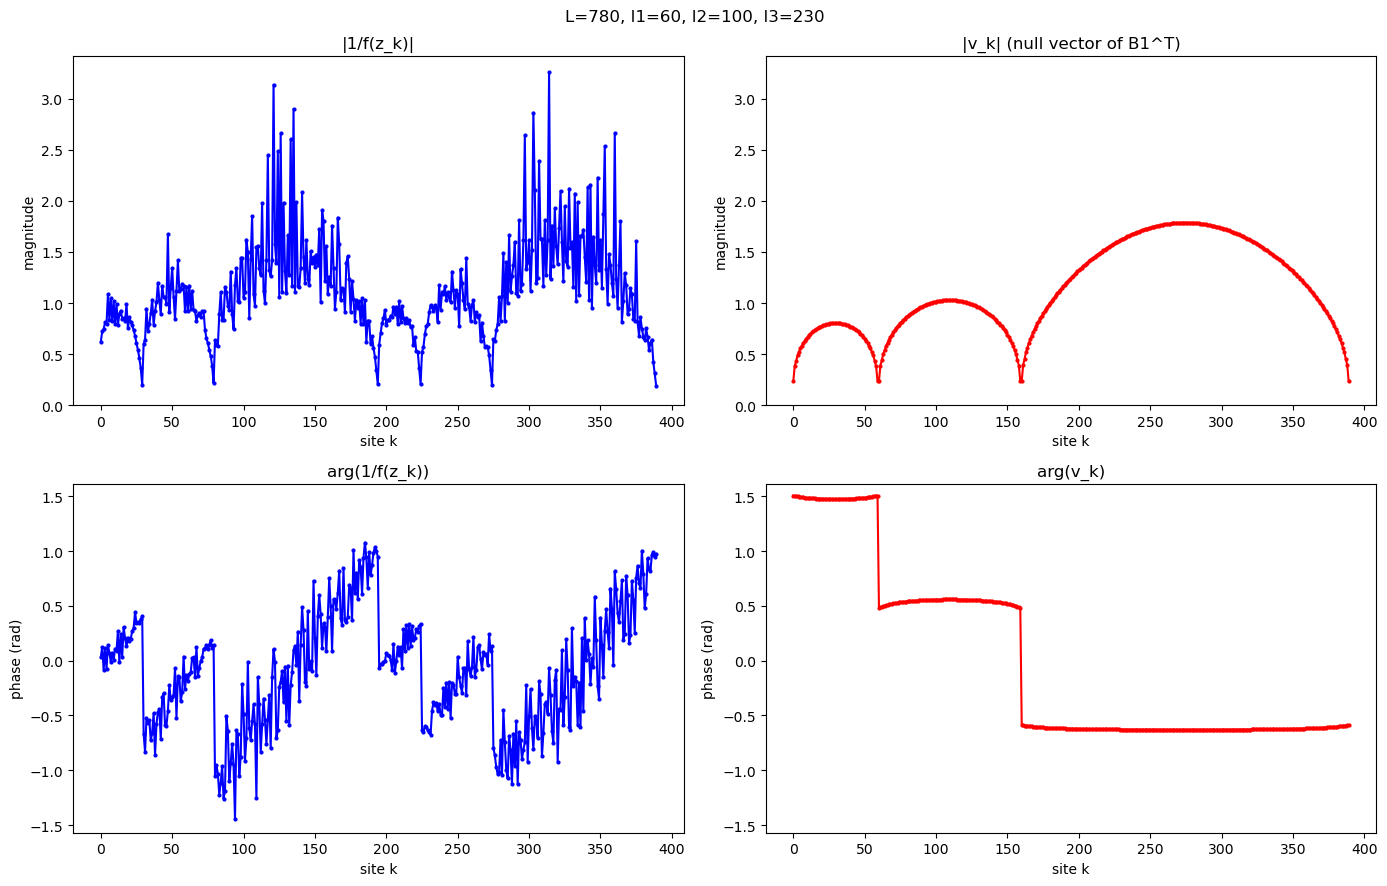

In [14]:
# Side-by-side comparison: |v_k| vs |1/f(z_k)| and phases
# Normalize v to have the same overall scale as 1/f for visual comparison
scale = np.linalg.norm(inv_f) / np.linalg.norm(v)
v_scaled = v * scale

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Top left: |1/f(z_k)|
axes[0,0].plot(np.abs(inv_f), 'b-o', markersize=2, label='|1/f(z_k)|')
axes[0,0].set_title('|1/f(z_k)|')
axes[0,0].set_xlabel('site k')
axes[0,0].set_ylabel('magnitude')

# Top right: |v_k|
axes[0,1].plot(np.abs(v_scaled), 'r-o', markersize=2, label='|v_k| (scaled)')
axes[0,1].set_title('|v_k| (null vector of B1^T)')
axes[0,1].set_xlabel('site k')
axes[0,1].set_ylabel('magnitude')

# Match y-axis limits for magnitude
ymax = max(axes[0,0].get_ylim()[1], axes[0,1].get_ylim()[1])
axes[0,0].set_ylim(0, ymax)
axes[0,1].set_ylim(0, ymax)

# Bottom left: arg(1/f(z_k))
axes[1,0].plot(np.angle(inv_f), 'b-o', markersize=2, label='arg(1/f(z_k))')
axes[1,0].set_title('arg(1/f(z_k))')
axes[1,0].set_xlabel('site k')
axes[1,0].set_ylabel('phase (rad)')

# Bottom right: arg(v_k)
axes[1,1].plot(np.angle(v_scaled), 'r-o', markersize=2, label='arg(v_k)')
axes[1,1].set_title('arg(v_k)')
axes[1,1].set_xlabel('site k')
axes[1,1].set_ylabel('phase (rad)')

# Match y-axis limits for phase
ymin = min(axes[1,0].get_ylim()[0], axes[1,1].get_ylim()[0])
ymax2 = max(axes[1,0].get_ylim()[1], axes[1,1].get_ylim()[1])
axes[1,0].set_ylim(ymin, ymax2)
axes[1,1].set_ylim(ymin, ymax2)

plt.suptitle(f'L={L}, l1={l1}, l2={l2}, l3={l3}')
plt.tight_layout()
plt.show()

In [ ]:
# Method 1 from Section 4a-bis: Constraint method
# Use the computed null vector v (from bmat_reduced SVD, not from cyl_eqn)
# Impose sum_k v_k c(k) = 0, eliminate c(L/2):
#   c(L/2) = -(1/v[L/2]) * sum_{j<L/2} v_j c(j)
# Build substitution matrix P: (L/2) x (L/2-1)
# Compute B_tilde = P^T @ B1: (L/2-1) x (L/2-1)

print(f'Using null vector v from SVD (residual: {np.max(np.abs(B1.T @ v)):.2e})')
print(f'v[-1] = {v[-1]}  (used to eliminate c(L/2))')

# Build P
P = np.eye(half, half - 1, dtype=np.complex128)  # (L/2) x (L/2-1), identity in top block
P[-1, :] = -v[:-1] / v[-1]                        # last row: -v_j / v_{L/2}

print(f'P shape: {P.shape}')

# Compute reduced ghost matrix
B_tilde = P.T @ B1  # (L/2-1) x (L/2-1)
print(f'B_tilde shape: {B_tilde.shape}')

# Determinant of B_tilde = ghost det with c zero mode removed
sign_bt, logabsdet_bt = np.linalg.slogdet(B_tilde)
print(f'\ndet(B_tilde):')
print(f'  sign = {sign_bt}')
print(f'  log|det| = {logabsdet_bt:.6f}')

# Compare with full det B
B_full = pf.bmat(L, l1, l2)
sign_B, logabsdet_B = np.linalg.slogdet(B_full)
print(f'\ndet(B) [full, with c zero mode]:')
print(f'  sign = {sign_B}')
print(f'  log|det| = {logabsdet_B:.6f}')

print(f'\nlog|det B| - log|det B_tilde| = {logabsdet_B - logabsdet_bt:.6f}')
print(f'  (this difference encodes the c zero mode contribution)')

k= 1  L=  78  log_num=-9.00877235  log_ana=-3.02390054  diff=-5.98e+00
k= 3  L= 234  log_num=-9.13127619  log_ana=-2.98727237  diff=-6.14e+00
k= 5  L= 390  log_num=-9.16723429  log_ana=-2.97906371  diff=-6.19e+00
k= 7  L= 546  log_num=-9.18395088  log_ana=-2.97572290  diff=-6.21e+00
k= 9  L= 702  log_num=-9.19352824  log_ana=-2.97396755  diff=-6.22e+00
k=11  L= 858  log_num=-9.19971651  log_ana=-2.97290532  diff=-6.23e+00
k=13  L=1014  log_num=-9.20404015  log_ana=-2.97220197  diff=-6.23e+00


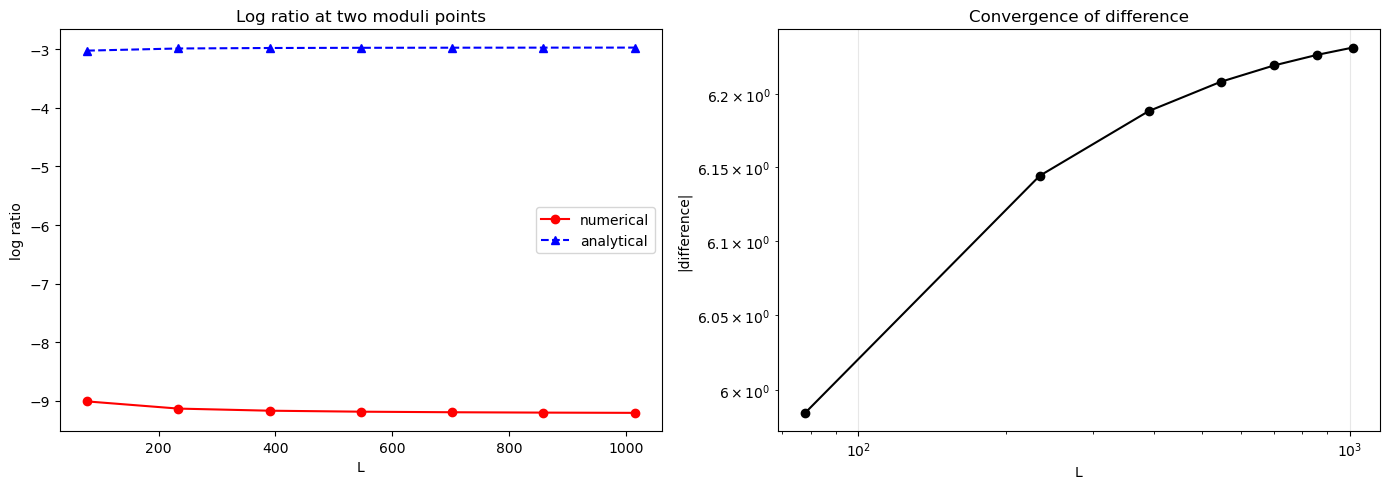

In [23]:
# Ratio test: (det'A)^{-13} * |det B_tilde|^2 vs jacobian * tau_2^{-13} * |eta|^{-48}
# Compare at two moduli points, varying L
import mpmath as mp

def compute_ghost_reduced_logdet(L, l1, l2):
    """Compute log|det(B_tilde)|^2 with c zero mode removed (Method 1: constraint)."""
    B1, v = pf.bmat_reduced(L, l1, l2)
    half = L // 2
    P = np.eye(half, half - 1, dtype=np.complex128)
    P[-1, :] = -v[:-1] / v[-1]
    B_tilde = P.T @ B1
    _, logabsdet = np.linalg.slogdet(B_tilde)
    return 2.0 * logabsdet  # log|det B_tilde|^2

# Two moduli points (scale with L via multiplier k)
# Point 1: l1=6k, l2=10k  (l3=23k)
# Point 2: l1=8k, l2=12k  (l3=19k)

k_values = [1, 3, 5, 7, 9,11,13]
results = []

for kk in k_values:
    L = 78 * kk
    L_num = 78*(kk+1)
    half = L // 2

    l1_1, l2_1 = 5*kk, 7*kk
    l1_1num,l2_1num = 5*(kk+1),7*(kk+1)
    l1_2, l2_2 = 3*kk, 1*kk
    l1_2num,l2_2num = 3*(kk+1),1*(kk+1)

    # --- Numerical: log[(det'A)^{-13} * |det B_tilde|^2] ---
    log_matter_1 = float(-13 * pf.prime_det_log(L_num, l1_1num, l2_1num))
    log_matter_2 = float(-13 * pf.prime_det_log(L_num, l1_2num, l2_2num))

    log_ghost_1 = compute_ghost_reduced_logdet(L_num, l1_1num, l2_1num)
    log_ghost_2 = compute_ghost_reduced_logdet(L_num, l1_2num, l2_2num)

    log_num_ratio = (log_matter_1 + log_ghost_1) - (log_matter_2 + log_ghost_2)

    # --- Analytic: jacobian * tau_2^{-13} * |eta|^{-48} ---
    fZ1, eta1, im_tau1, b1, jac1, tau1, P1_1 = et.compute_rhs(L, l1_1, l2_1)
    fZ2, eta2, im_tau2, b2, jac2, tau2, P1_2 = et.compute_rhs(L, l1_2, l2_2)

    ana_1 = abs(P1_1)**(-4) * float(im_tau1)**(-13) * float(abs(eta1))**(-48)
    ana_2 = abs(P1_2)**(-4) * float(im_tau2)**(-13) * float(abs(eta2))**(-48)
    log_ana_ratio = np.log(ana_1) - np.log(ana_2)

    diff = log_num_ratio - log_ana_ratio
    results.append((L, log_num_ratio, log_ana_ratio, diff))
    print(f'k={kk:2d}  L={L:4d}  log_num={log_num_ratio:+.8f}  log_ana={log_ana_ratio:+.8f}  diff={diff:+.2e}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

Ls   = [r[0] for r in results]
nums = [r[1] for r in results]
anas = [r[2] for r in results]
diffs= [r[3] for r in results]

axes[0].plot(Ls, nums, 'ro-', label="numerical")
axes[0].plot(Ls, anas, 'b^--', label="analytical")
axes[0].set_xlabel('L')
axes[0].set_ylabel('log ratio')
axes[0].legend()
axes[0].set_title('Log ratio at two moduli points')

axes[1].plot(Ls, [abs(d) for d in diffs], 'ko-')
axes[1].set_xlabel('L')
axes[1].set_ylabel('|difference|')
axes[1].set_yscale('log')
axes[1].set_xscale('log')
axes[1].set_title('Convergence of difference')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Previously, I can find \hat{f} by looking at the zero modes of the identity wavefunctional for the bc ghost. That is, I had found the null vector of "def bmat_reduced(L: int, l1: int, l2: int, dtype=np.complex128):
    """
    Compute B with the m=1 column removed and its left null vector.

    B1 = B[:, 1:]  has shape (L/2) x (L/2-1).
    The left null vector v satisfies B1^T v = 0, i.e.
      sum_k B1[k,m] v[k] = 0  for all m = 2,...,L/2.
    In the continuum limit v_k -> 1/f(z_k).

    Returns
    -------
    B1 : ndarray, shape (L/2, L/2-1)
        The B matrix with the first mode column removed.
    v : ndarray, shape (L/2,)
        The left null vector (unit-normalized).
    """
    B = bmat(L, l1, l2, dtype=dtype)
    B1 = B[:, 1:]  # remove m=1 column
    # Need null(B1^T), not null(B1^H). For complex matrices these differ.
    # SVD of B1^T: the right null vector gives null(B1^T).
    _, _, Vh = np.linalg.svd(B1.T, full_matrices=True)
    v = Vh[-1, :].conj()  # null vector of B1^T
    return B1, v" and this matched 1/f perfectly, where "def bmat(L: int, l1: int, l2: int, dtype=np.complex128) -> np.ndarray:
    """
    Python/Numpy version of Mathematica:

    Bmat[L_, l1_, l2_] := Join[
      k1=1..l1:   exp(2π i m k1/L) - exp(2π i m/L (L/2 + l1 + 1 - k1))
      k2=l1+1..l1+l2: exp(2π i m k2/L) - exp(2π i m/L (L/2 + 2 l1 + l2 + 1 - k2))
      k3=l1+l2+1..L/2: exp(2π i m k3/L) - exp(2π i m/L (L + l1 + l2 + 1 - k3))
    ]

    Returns a (L/2) x (L/2) complex matrix with rows ordered by k=1..L/2
    and columns by m=1..L/2.
    """
    assert L % 2 == 0, "L must be even"
    half = L // 2

    m = np.arange(1, half + 1, dtype=np.float64)  # m=1..L/2
    twopi_i_over_L = 2j * np.pi / L

    rows = []

    # Block 1: k1 = 1..l1
    for k in range(1, l1 + 1):
        a = np.exp(twopi_i_over_L * (m * k))
        b = np.exp(twopi_i_over_L * (m * (half + l1 + 1 - k)))
        rows.append(a - b)

    # Block 2: k2 = l1+1 .. l1+l2
    for k in range(l1 + 1, l1 + l2 + 1):
        a = np.exp(twopi_i_over_L * (m * k))
        b = np.exp(twopi_i_over_L * (m * (half + 2 * l1 + l2 + 1 - k)))
        rows.append(a - b)

    # Block 3: k3 = l1+l2+1 .. L/2
    for k in range(l1 + l2 + 1, half + 1):
        a = np.exp(twopi_i_over_L * (m * k))
        b = np.exp(twopi_i_over_L * (m * (L + l1 + l2 + 1 - k)))
        rows.append(a - b)

    B = np.vstack(rows).astype(dtype, copy=False)
    assert B.shape == (half, half), f"Expected {(half, half)}, got {B.shape}"
    return B" Can something be done in the case of genus 2 as well? As a reminder, here is the attached .tex file of the reasoning. See if you can come up with a way for the genus 2 to find basis of holomorphic one forms just by looking at the null vector of some reduced version of B, where B corresponds